# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [55]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

for name, model in base_models.items():
    cv = cross_val_score(estimator=model, X=X_test, y=y_test, cv=5, scoring='f1_macro')
    meancv = np.mean(cv)
    stdcv = np.std(cv)
    baseline_results[name] = (meancv, stdcv)

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9414 ± 0.0375
RandomForest              F1 = 0.9417 ± 0.0222
LogisticRegression        F1 = 0.9414 ± 0.0375


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [57]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    "svm__C" : [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf','linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(estimator=svm_pipe, param_grid=svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [58]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

grid_results = pd.DataFrame(svm_grid_search.cv_results_, columns=['params', 'mean_test_score', 'std_test_score', 'rank_test_score'])
display(grid_results.sort_values(by='rank_test_score').head(10))

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),                         
    'max_depth': [randint(2, 20), None],                     
    'min_samples_split': randint(2, 20),                         
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=rf_param_dist,n_iter=50, cv=5, scoring='f1_macro',random_state=42, n_jobs=-1)
rf_random_search.fit(X_train, y_train)
print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 7, 'n_estimators': 103}
Лучший CV F1: 0.9577


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [60]:
from sklearn.metrics import classification_report

grid_search_preds = svm_grid_search.best_estimator_.predict(X_test)
random_search_preds = rf_random_search.best_estimator_.predict(X_test)
grid_search_f1_test = f1_score(y_test, grid_search_preds)
random_search_f1_test = f1_score(y_test, random_search_preds)

results = {
    "SVM Gridsearch": [svm_grid_search.best_score_, svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_], grid_search_f1_test],
    "RF RandomSearch": [rf_random_search.best_score_, rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_], random_search_f1_test],
}
print(classification_report(y_test, grid_search_preds))
print(classification_report(y_test, random_search_preds))


for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_test = f1_score(y_test, y_pred)
    print(classification_report(y_test, y_pred))
    results[name] = [baseline_results[name][0], baseline_results[name][1], f1_test]

print(f"# | {'Модель':20s} | {'CV F1 (mean±std)':16s} | {'Test F1':7s} |")
print(f"# |{'-'*22}|{'-'*18}|{'-'*9}|")

rows = [
    ("SVM baseline",       "SVM"),
    ("SVM Grid Search",    "SVM Gridsearch"),
    ("RF baseline",        "RandomForest"),
    ("RF Random Search",   "RF RandomSearch"),
]

for label, key in rows:
    mean, std, test = results[key]
    print(f"# | {label:20s} | {mean:.4f}±{std:.4f}    | {test:.4f}  |")
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

              preci

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

Text(0.5, 1.0, 'Permutation Importance')

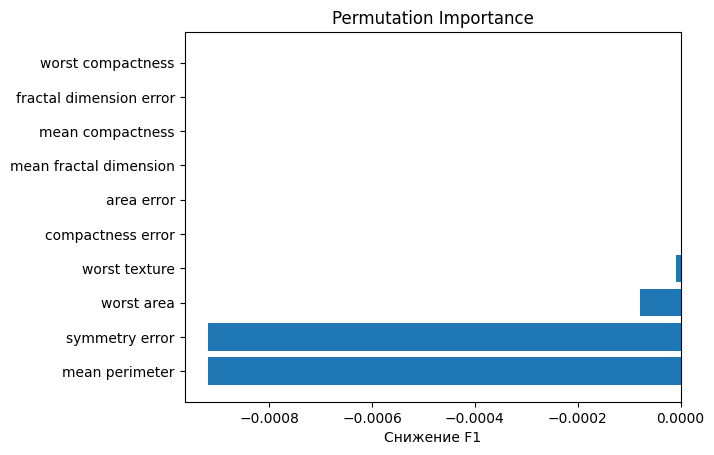

In [80]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf,X_test,y_test,n_repeats=10, random_state=42, scoring='f1_macro' )
idx = pi_result.importances_mean.argsort()
idx = idx[20:]
plt.barh(X_train.columns[idx], pi_result.importances_mean[idx])
plt.xlabel('Снижение F1')
plt.title('Permutation Importance')

# Построим bar plot топ-10 признаков
# YOUR CODE HERE

Text(0.5, 1.0, 'Permutation Importance')

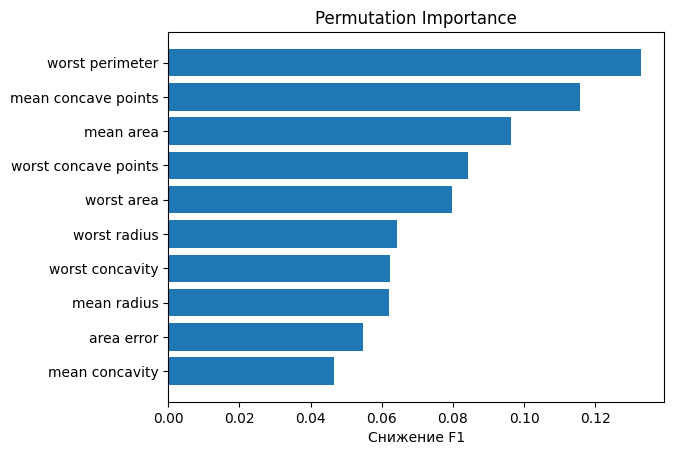

In [77]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

FI_result = best_rf.feature_importances_
index = FI_result.argsort()
index = index[20:]
plt.barh(X_train.columns[index], FI_result[index])
plt.xlabel('Снижение F1')
plt.title('Permutation Importance')

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Топ-5 признаков не совпал от слова совсем.
Некоторые Фичи могут иметь высокий PI, но низкую встроенную важность, что может означать скоррелированность данных - Feature importances распределяется равномерно между скоррелированными данными, но от перемешивания одного из них во время подсчета PI точность модели сильно падает, т.к.этот признак на самом деле вносит важный вклад

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

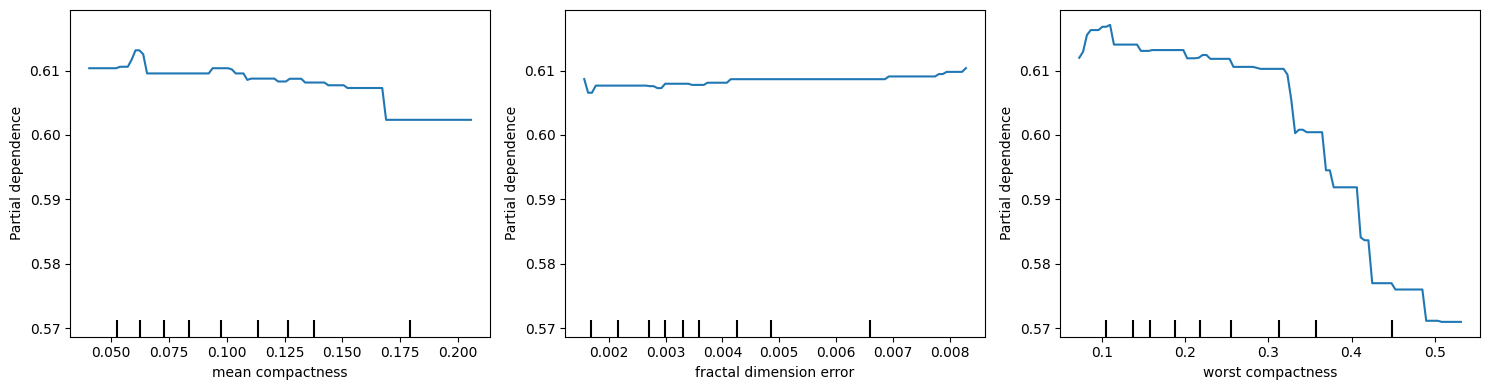

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = pi_result.importances_mean.argsort()[-3:]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(best_rf, X_test, features=top3_idx, kind='average', ax=ax)
plt.tight_layout()
plt.show()

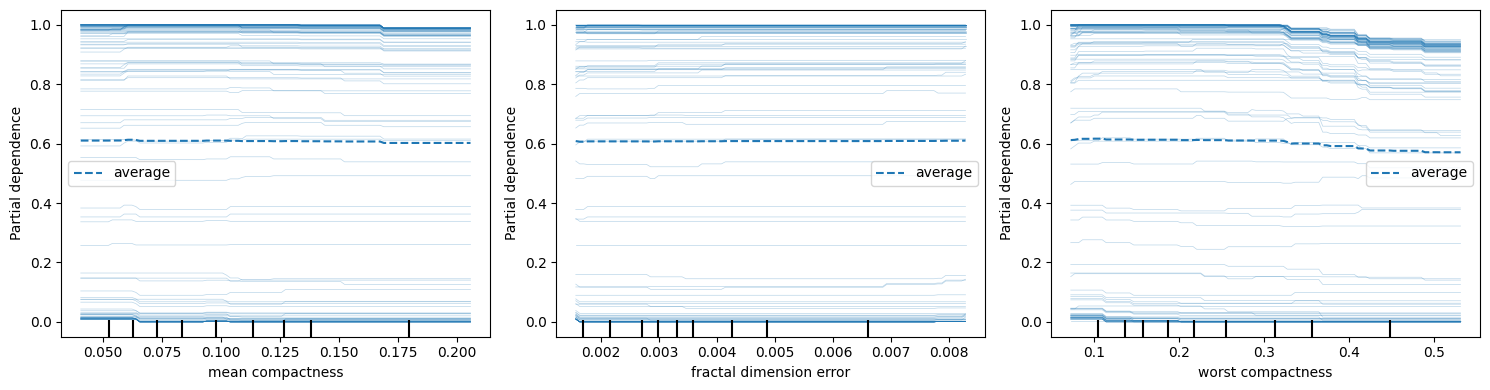

In [82]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(best_rf, X_test, features=top3_idx, kind='both', ax=ax)
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [101]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap
shap.initjs()
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

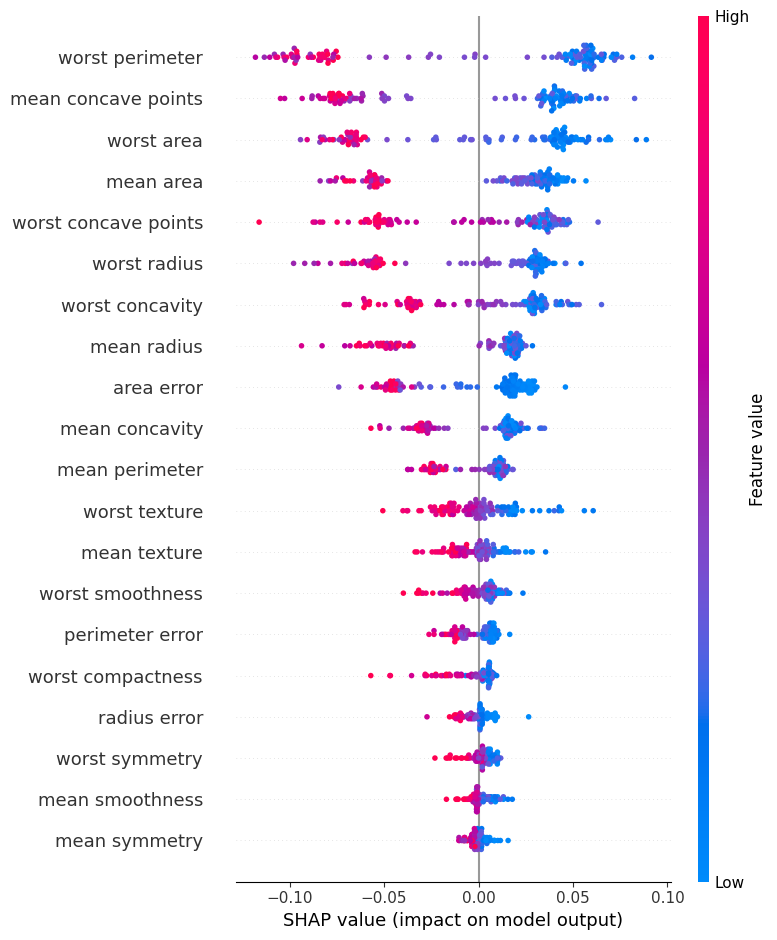

In [104]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝SSS

shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns)

In [103]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
shap.force_plot(explainer.expected_value[0], shap_values[0, :, 0], X_test.iloc[0], feature_names=X_test.columns)


Число ошибок: 6
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [105]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Text(0.5, 1.0, 'Permutation Importance')

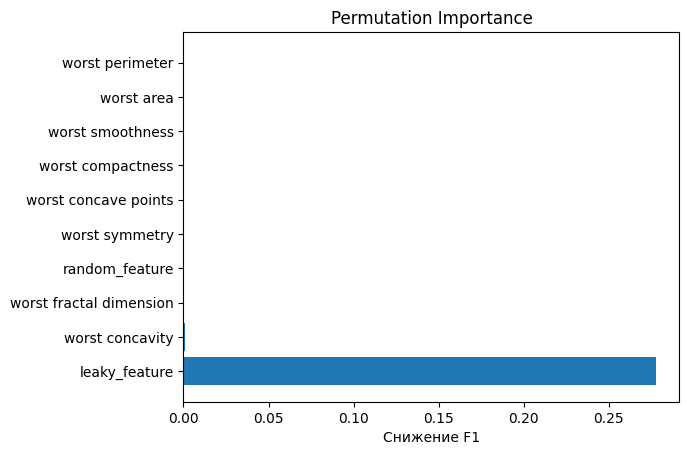

In [116]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝
leakedRF = RandomForestClassifier()
leakedRF.fit(X_train_ext, y_train)
pi_leakedRF = permutation_importance(leakedRF,X_test_ext,y_test,n_repeats=10, random_state=42, scoring='f1_macro' )
idx_leaked = pi_leakedRF.importances_mean.argsort()[::-1]
idx_leaked = idx_leaked[:10]
plt.barh(X_train_ext.columns[idx_leaked], pi_leakedRF.importances_mean[idx_leaked])
plt.xlabel('Снижение F1')
plt.title('Permutation Importance')

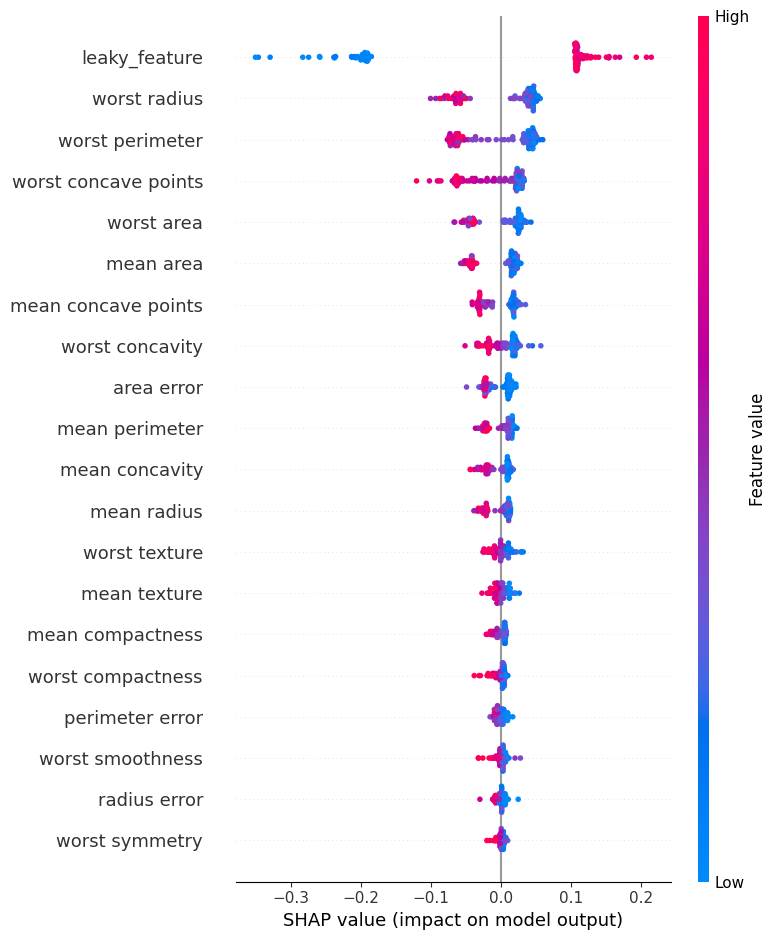

In [117]:

explainer_leakedRF = shap.TreeExplainer(leakedRF)
shap_values_leakedRF = explainer_leakedRF.shap_values(X_test_ext)
shap.summary_plot(shap_values_leakedRF[:, :, 1], X_test_ext, feature_names=X_test_ext.columns)
# YOUR CODE HERE

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [122]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

rows = [
    ("SVM baseline",     "SVM",            "Уже высокий F1 на базовой модели"),
    ("SVM Grid Search",  "SVM Gridsearch", "CV вырос, но Test F1 не изменился"),
    ("RF baseline",      "RandomForest",   "Слабее SVM на этих данных, но также имеет высокий F1"),
    ("RF Rand Search",   "RF RandomSearch","CV вырос, Test F1 немного упал"),
]

print(f"# | {'Метод':20s} | {'CV F1':15s} | {'Test F1':7s} | {'Выводы':40s} |")
print(f"# |{'-'*22}|{'-'*17}|{'-'*9}|{'-'*42}|")
for label, key, conclusion in rows:
    mean, std, test = table[key]
    print(f"# | {label:20s} | {mean:.4f}±{std:.4f}   |  {test:.4f} | {conclusion:40s} |")

# | Метод                | CV F1           | Test F1 | Выводы                                   |
# |----------------------|-----------------|---------|------------------------------------------|
# | SVM baseline         | 0.9717±0.0159   |  0.9861 | Уже высокий F1 на базовой модели         |
# | SVM Grid Search      | 0.9786±0.0176   |  0.9861 | CV вырос, но Test F1 не изменился        |
# | RF baseline          | 0.9528±0.0244   |  0.9655 | Слабее SVM на этих данных, но также имеет высокий F1 |
# | RF Rand Search       | 0.9577±0.0207   |  0.9655 | CV вырос, Test F1 немного упал           |


# Ответы на вопросы:
1. Насколько тюнинг улучшил модели? Подбор гиперпараметров что в одном, что в другом случае помог немного улучшить CV F1, но на тест F! это не отобразилось совсем. Думаю, это произошло из-за 1) небольших размеров и 2) Изначально высокого F1 на бейзланах. Видимо, датасет нетрудно разделим и базовыми моделями со стандартными парметрами (уже хорошо подходящими), что в совокупности с небольшими размерами не дает улучшенным гиперпараметрам себя проявить.
2. Совпадают ли топ-признаки по PI и SHAP? Если нет — почему? Да. в отличии от FI, топ-признаки SHAP те же, что и у PI (только порядок немного другой) 
3. Что было бы, если бы мы не использовали Pipeline? Данные бы скейлились и на тестовых, и на валидационных выборках, произошла бы утечка данных
4. Как бы вы использовали PI и SHAP в реальном проекте? SHAP - для интрепретации конкретных (локальных) случаев - условно, по какой причине человеку не выдали кредит или предложили именно эту акцию; для проверки data leackage. PI - также для проверки data leackage; для отсева не влияющих на результат признаков и для глобальной интрепретации (и обьяснения заказчику) важных фич для модели

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")